# MALLORN Astronomical Classification Challenge — v2

**Goal**: Identify Tidal Disruption Events (TDEs) from simulated LSST light curves.

**Metric**: F1 Score (binary classification)

**Key improvements over v1**:
1. **Enhanced feature engineering** — Bazin function fits, structure function, autocorrelation, flux asymmetry, rolling statistics
2. **Stronger models** — CatBoost + BalancedRandomForest added to ensemble
3. **SMOTE oversampling** within CV folds to address extreme class imbalance
4. **Stacking** with logistic regression meta-learner instead of simple weight search
5. **10-fold CV** for more stable estimates with only 64 TDEs
6. **Robust threshold selection** via inner CV to prevent overfitting

## 1. Setup & Imports

In [4]:
!pip install catboost imbalanced-learn -q

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
from scipy import stats
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore")

DATA_DIR = "/Users/jackietan/Documents/workshop/academic/csc753m/kaggle_project/mallorn-astronomical-classification-challenge/data"
FILTERS = ["u", "g", "r", "i", "z", "y"]
N_SPLITS = 20
SEED = 42
np.random.seed(SEED)

## 2. Load Data

In [6]:
train_log = pd.read_csv(os.path.join(DATA_DIR, "train_log.csv"))
test_log = pd.read_csv(os.path.join(DATA_DIR, "test_log.csv"))

print(f"Train: {len(train_log)} objects ({train_log['target'].sum()} TDEs, {len(train_log) - train_log['target'].sum()} non-TDEs)")
print(f"Test:  {len(test_log)} objects")
print(f"TDE ratio: {train_log['target'].mean():.2%}")

train_lcs, test_lcs = [], []
for i in tqdm(range(1, N_SPLITS + 1), desc="Loading splits"):
    d = os.path.join(DATA_DIR, f"split_{i:02d}")
    train_lcs.append(pd.read_csv(os.path.join(d, "train_full_lightcurves.csv")))
    test_lcs.append(pd.read_csv(os.path.join(d, "test_full_lightcurves.csv")))

train_lc = pd.concat(train_lcs, ignore_index=True)
test_lc = pd.concat(test_lcs, ignore_index=True)
del train_lcs, test_lcs

print(f"Train LC rows: {len(train_lc):,}")
print(f"Test  LC rows: {len(test_lc):,}")

Train: 3043 objects (148 TDEs, 2895 non-TDEs)
Test:  7135 objects
TDE ratio: 4.86%


Loading splits:   0%|          | 0/20 [00:00<?, ?it/s]

Train LC rows: 479,384
Test  LC rows: 1,145,125


## 3. Enhanced Feature Engineering

New features compared to v1:
- **Bazin function fit** — parametric model for transient light curves (amplitude, rise time, fall time)
- **Structure function** — measures variability as a function of time lag
- **Autocorrelation** — temporal correlation at different lags
- **Flux asymmetry** — difference between above/below median behavior
- **Rolling statistics** — windowed mean/std to capture local behavior
- **Enhanced per-filter features** — more ratios and cross-band correlations

In [7]:
def safe_stat(arr, func, default=0):
    try:
        if len(arr) < 2:
            return default
        val = func(arr)
        return val if np.isfinite(val) else default
    except Exception:
        return default


def compute_weighted_mean(flux, flux_err):
    w = 1.0 / (flux_err**2 + 1e-10)
    return np.sum(flux * w) / np.sum(w)


def compute_stetson_j(flux, flux_err):
    if len(flux) < 3:
        return 0
    mean = compute_weighted_mean(flux, flux_err)
    residuals = (flux - mean) / (flux_err + 1e-10)
    n = len(flux)
    pairs = residuals[:-1] * residuals[1:]
    sign_pairs = np.sign(pairs)
    return np.sum(sign_pairs * np.sqrt(np.abs(pairs))) / n


def compute_stetson_k(flux, flux_err):
    """Stetson K — measures kurtosis of the magnitude distribution."""
    if len(flux) < 3:
        return 0
    mean = compute_weighted_mean(flux, flux_err)
    residuals = (flux - mean) / (flux_err + 1e-10)
    n = len(flux)
    return np.sum(np.abs(residuals)) / (n * np.sqrt(np.sum(residuals**2) / n) + 1e-10)


def compute_von_neumann_ratio(flux):
    if len(flux) < 3:
        return 0
    var = np.var(flux)
    if var < 1e-10:
        return 0
    return np.mean(np.diff(flux)**2) / var


def bazin_func(t, A, t0, t_rise, t_fall, c):
    """Bazin function for transient light curve fitting."""
    return A * np.exp(-(t - t0) / t_fall) / (1 + np.exp(-(t - t0) / t_rise)) + c


def fit_bazin(time, flux):
    """Fit Bazin function, return parameters or defaults on failure."""
    defaults = {"bazin_A": 0, "bazin_t_rise": 0, "bazin_t_fall": 0,
                "bazin_c": 0, "bazin_rise_fall_ratio": 0, "bazin_fit_residual": 1e6}
    if len(time) < 6:
        return defaults
    try:
        t_norm = time - time[0]
        A0 = np.max(flux) - np.min(flux)
        t0_0 = t_norm[np.argmax(flux)]
        p0 = [A0, t0_0, 20.0, 40.0, np.median(flux)]
        bounds = ([0, 0, 0.1, 0.1, -np.inf], [np.inf, t_norm[-1] * 2, 500, 500, np.inf])
        popt, _ = curve_fit(bazin_func, t_norm, flux, p0=p0, bounds=bounds,
                           maxfev=1000, method='trf')
        A, t0, t_rise, t_fall, c = popt
        residual = np.mean((flux - bazin_func(t_norm, *popt))**2)
        return {"bazin_A": A, "bazin_t_rise": t_rise, "bazin_t_fall": t_fall,
                "bazin_c": c, "bazin_rise_fall_ratio": t_rise / (t_fall + 1e-10),
                "bazin_fit_residual": residual}
    except Exception:
        return defaults


def compute_structure_function(time, flux, lags=[5, 20, 50, 100]):
    """Structure function at given time lags."""
    feats = {}
    if len(time) < 3:
        for lag in lags:
            feats[f"sf_lag{lag}"] = 0
        return feats
    for lag in lags:
        diffs = []
        for i in range(len(time)):
            for j in range(i + 1, min(i + 50, len(time))):
                dt = abs(time[j] - time[i])
                if lag * 0.5 <= dt <= lag * 1.5:
                    diffs.append((flux[j] - flux[i])**2)
        feats[f"sf_lag{lag}"] = np.mean(diffs) if diffs else 0
    return feats


def compute_autocorrelation(flux, lags=[1, 2, 5, 10]):
    """Autocorrelation at given lags."""
    feats = {}
    n = len(flux)
    if n < 12:
        for lag in lags:
            feats[f"autocorr_lag{lag}"] = 0
        return feats
    mean = np.mean(flux)
    var = np.var(flux)
    if var < 1e-10:
        for lag in lags:
            feats[f"autocorr_lag{lag}"] = 0
        return feats
    for lag in lags:
        if lag >= n:
            feats[f"autocorr_lag{lag}"] = 0
        else:
            c = np.mean((flux[:n-lag] - mean) * (flux[lag:] - mean)) / var
            feats[f"autocorr_lag{lag}"] = c if np.isfinite(c) else 0
    return feats

In [8]:
def extract_features_v2(group):
    """Extract all features from one object's light curve — v2 enhanced."""
    feats = {}
    flux = group["Flux"].values
    flux_err = group["Flux_err"].values
    time = group["Time (MJD)"].values
    filters = group["Filter"].values

    sort_idx = np.argsort(time)
    flux_s = flux[sort_idx]
    time_s = time[sort_idx]
    flux_err_s = flux_err[sort_idx]
    filters_s = filters[sort_idx]
    n = len(flux)

    # ========== Global basic stats ==========
    feats["n_obs"] = n
    feats["flux_mean"] = np.mean(flux)
    feats["flux_std"] = np.std(flux) if n > 1 else 0
    feats["flux_median"] = np.median(flux)
    feats["flux_min"] = np.min(flux)
    feats["flux_max"] = np.max(flux)
    feats["flux_range"] = feats["flux_max"] - feats["flux_min"]
    feats["flux_skew"] = safe_stat(flux, stats.skew)
    feats["flux_kurtosis"] = safe_stat(flux, stats.kurtosis)
    feats["flux_iqr"] = np.percentile(flux, 75) - np.percentile(flux, 25)
    feats["flux_p5"] = np.percentile(flux, 5)
    feats["flux_p10"] = np.percentile(flux, 10)
    feats["flux_p25"] = np.percentile(flux, 25)
    feats["flux_p75"] = np.percentile(flux, 75)
    feats["flux_p90"] = np.percentile(flux, 90)
    feats["flux_p95"] = np.percentile(flux, 95)
    feats["flux_above_mean_frac"] = np.mean(flux > feats["flux_mean"])
    feats["flux_positive_frac"] = np.mean(flux > 0)
    feats["flux_mad"] = np.median(np.abs(flux - feats["flux_median"]))
    feats["flux_wmean"] = compute_weighted_mean(flux, flux_err)
    feats["flux_cv"] = feats["flux_std"] / (abs(feats["flux_mean"]) + 1e-10)  # coefficient of variation

    # ========== Flux asymmetry (NEW) ==========
    above = flux[flux > feats["flux_median"]]
    below = flux[flux <= feats["flux_median"]]
    feats["flux_asymmetry"] = (np.mean(above) - abs(np.mean(below))) / (feats["flux_range"] + 1e-10) if len(above) > 0 and len(below) > 0 else 0
    feats["flux_above_std"] = np.std(above) if len(above) > 1 else 0
    feats["flux_below_std"] = np.std(below) if len(below) > 1 else 0
    feats["flux_std_ratio"] = feats["flux_above_std"] / (feats["flux_below_std"] + 1e-10)

    # ========== Error features ==========
    feats["flux_err_mean"] = np.mean(flux_err)
    feats["flux_err_std"] = np.std(flux_err) if n > 1 else 0
    feats["flux_err_median"] = np.median(flux_err)
    snr = np.abs(flux) / (flux_err + 1e-10)
    feats["snr_mean"] = np.mean(snr)
    feats["snr_max"] = np.max(snr)
    feats["snr_std"] = np.std(snr) if n > 1 else 0
    feats["snr_median"] = np.median(snr)
    feats["high_snr_frac"] = np.mean(snr > 3)  # fraction with SNR > 3

    # ========== Time features ==========
    feats["time_span"] = np.ptp(time_s) if n > 1 else 0
    feats["n_unique_nights"] = len(np.unique(np.round(time_s)))

    if n > 1:
        dt = np.diff(time_s)
        feats["dt_mean"] = np.mean(dt)
        feats["dt_std"] = np.std(dt)
        feats["dt_min"] = np.min(dt)
        feats["dt_max"] = np.max(dt)
        feats["dt_median"] = np.median(dt)
        dflux = np.diff(flux_s)
        rates = dflux / (dt + 1e-10)
        feats["flux_rate_mean"] = np.mean(rates)
        feats["flux_rate_std"] = np.std(rates)
        feats["flux_rate_max"] = np.max(rates)
        feats["flux_rate_min"] = np.min(rates)
        feats["flux_rate_abs_max"] = np.max(np.abs(rates))
        feats["flux_rate_pos_frac"] = np.mean(rates > 0)
        feats["flux_rate_skew"] = safe_stat(rates, stats.skew)
        feats["flux_rate_kurtosis"] = safe_stat(rates, stats.kurtosis)
    else:
        for k in ["dt_mean", "dt_std", "dt_min", "dt_max", "dt_median",
                   "flux_rate_mean", "flux_rate_std", "flux_rate_max",
                   "flux_rate_min", "flux_rate_abs_max", "flux_rate_pos_frac",
                   "flux_rate_skew", "flux_rate_kurtosis"]:
            feats[k] = 0

    # ========== Peak analysis ==========
    peak_idx = np.argmax(flux_s)
    feats["peak_flux"] = flux_s[peak_idx]
    feats["peak_phase"] = (time_s[peak_idx] - time_s[0]) / (feats["time_span"] + 1e-10) if n > 1 else 0.5
    feats["peak_time_from_start"] = time_s[peak_idx] - time_s[0]

    # Rise and decline
    if peak_idx > 0:
        rise_flux = flux_s[:peak_idx + 1]
        rise_time = time_s[:peak_idx + 1]
        feats["rise_rate"] = (rise_flux[-1] - rise_flux[0]) / (rise_time[-1] - rise_time[0] + 1e-10)
        feats["rise_duration"] = rise_time[-1] - rise_time[0]
        feats["rise_n_obs"] = len(rise_flux)
    else:
        feats["rise_rate"] = 0
        feats["rise_duration"] = 0
        feats["rise_n_obs"] = 0

    if peak_idx < n - 1:
        dec_flux = flux_s[peak_idx:]
        dec_time = time_s[peak_idx:]
        feats["decline_rate"] = (dec_flux[-1] - dec_flux[0]) / (dec_time[-1] - dec_time[0] + 1e-10)
        feats["decline_duration"] = dec_time[-1] - dec_time[0]
        feats["decline_n_obs"] = len(dec_flux)
    else:
        feats["decline_rate"] = 0
        feats["decline_duration"] = 0
        feats["decline_n_obs"] = 0

    feats["rise_decline_ratio"] = feats["rise_duration"] / (feats["decline_duration"] + 1e-10)
    feats["amplitude_snr"] = feats["flux_range"] / (feats["flux_err_mean"] + 1e-10)
    feats["rise_rate_abs"] = abs(feats["rise_rate"])
    feats["decline_rate_abs"] = abs(feats["decline_rate"])
    feats["rise_decline_rate_ratio"] = feats["rise_rate_abs"] / (feats["decline_rate_abs"] + 1e-10)

    # ========== Variability indices ==========
    feats["stetson_j"] = compute_stetson_j(flux_s, flux_err_s)
    feats["stetson_k"] = compute_stetson_k(flux_s, flux_err_s)  # NEW
    feats["von_neumann"] = compute_von_neumann_ratio(flux_s)
    mean_err_sq = np.mean(flux_err**2)
    feats["excess_variance"] = (np.var(flux) - mean_err_sq) / (feats["flux_mean"]**2 + 1e-10)
    # Weighted std
    w = 1.0 / (flux_err**2 + 1e-10)
    wmean = feats["flux_wmean"]
    feats["flux_wstd"] = np.sqrt(np.sum(w * (flux - wmean)**2) / np.sum(w)) if n > 1 else 0

    # Number of peaks
    if n > 5:
        try:
            peaks, _ = find_peaks(flux_s, height=feats["flux_mean"])
            feats["n_peaks"] = len(peaks)
            peaks_low, _ = find_peaks(-flux_s, height=-feats["flux_mean"])
            feats["n_dips"] = len(peaks_low)
        except Exception:
            feats["n_peaks"] = 0
            feats["n_dips"] = 0
    else:
        feats["n_peaks"] = 0
        feats["n_dips"] = 0

    # ========== Bazin function fit (NEW) ==========
    bazin_feats = fit_bazin(time_s, flux_s)
    feats.update(bazin_feats)

    # ========== Structure function (NEW) ==========
    sf_feats = compute_structure_function(time_s, flux_s)
    feats.update(sf_feats)

    # ========== Autocorrelation (NEW) ==========
    ac_feats = compute_autocorrelation(flux_s)
    feats.update(ac_feats)

    # ========== Rolling statistics (NEW) ==========
    if n >= 10:
        w_size = max(n // 5, 5)
        rolling_means = [np.mean(flux_s[i:i+w_size]) for i in range(0, n - w_size + 1, w_size // 2)]
        rolling_stds = [np.std(flux_s[i:i+w_size]) for i in range(0, n - w_size + 1, w_size // 2)]
        feats["rolling_mean_std"] = np.std(rolling_means) if len(rolling_means) > 1 else 0
        feats["rolling_mean_range"] = np.ptp(rolling_means) if rolling_means else 0
        feats["rolling_std_mean"] = np.mean(rolling_stds) if rolling_stds else 0
        feats["rolling_std_max"] = np.max(rolling_stds) if rolling_stds else 0
    else:
        feats["rolling_mean_std"] = 0
        feats["rolling_mean_range"] = 0
        feats["rolling_std_mean"] = 0
        feats["rolling_std_max"] = 0

    # ========== Consecutive increase/decrease runs (NEW) ==========
    if n > 2:
        diffs = np.diff(flux_s)
        signs = np.sign(diffs)
        # Longest consecutive increase
        max_inc = max_dec = cur_inc = cur_dec = 0
        for s in signs:
            if s > 0:
                cur_inc += 1
                cur_dec = 0
            elif s < 0:
                cur_dec += 1
                cur_inc = 0
            else:
                cur_inc = 0
                cur_dec = 0
            max_inc = max(max_inc, cur_inc)
            max_dec = max(max_dec, cur_dec)
        feats["max_consecutive_increase"] = max_inc
        feats["max_consecutive_decrease"] = max_dec
    else:
        feats["max_consecutive_increase"] = 0
        feats["max_consecutive_decrease"] = 0

    # ========== Per-filter features ==========
    band_means = {}
    band_stds = {}
    band_peak_flux = {}
    band_peak_times = {}
    for filt in FILTERS:
        mask = filters == filt
        f_flux = flux[mask]
        f_err = flux_err[mask]
        f_time = time[mask]
        prefix = f"f_{filt}_"
        feats[prefix + "n"] = len(f_flux)

        if len(f_flux) > 0:
            feats[prefix + "mean"] = np.mean(f_flux)
            feats[prefix + "std"] = np.std(f_flux) if len(f_flux) > 1 else 0
            feats[prefix + "max"] = np.max(f_flux)
            feats[prefix + "min"] = np.min(f_flux)
            feats[prefix + "range"] = feats[prefix + "max"] - feats[prefix + "min"]
            feats[prefix + "skew"] = safe_stat(f_flux, stats.skew)
            feats[prefix + "kurtosis"] = safe_stat(f_flux, stats.kurtosis)
            feats[prefix + "snr"] = np.mean(np.abs(f_flux) / (f_err + 1e-10))
            feats[prefix + "wmean"] = compute_weighted_mean(f_flux, f_err)
            feats[prefix + "mad"] = np.median(np.abs(f_flux - np.median(f_flux)))
            feats[prefix + "p10"] = np.percentile(f_flux, 10)
            feats[prefix + "p90"] = np.percentile(f_flux, 90)
            feats[prefix + "positive_frac"] = np.mean(f_flux > 0)
            feats[prefix + "cv"] = feats[prefix + "std"] / (abs(feats[prefix + "mean"]) + 1e-10)
            band_means[filt] = feats[prefix + "mean"]
            band_stds[filt] = feats[prefix + "std"]
            band_peak_flux[filt] = feats[prefix + "max"]

            if len(f_flux) > 2:
                si = np.argsort(f_time)
                fs = f_flux[si]
                ts = f_time[si]
                dt_f = np.diff(ts)
                df_f = np.diff(fs)
                rates_f = df_f / (dt_f + 1e-10)
                feats[prefix + "rate_max"] = np.max(np.abs(rates_f))
                feats[prefix + "rate_mean"] = np.mean(rates_f)
                pk = np.argmax(fs)
                feats[prefix + "peak_phase"] = (ts[pk] - ts[0]) / (ts[-1] - ts[0] + 1e-10)
                feats[prefix + "stetson_j"] = compute_stetson_j(f_flux[si], f_err[si])
                feats[prefix + "von_neumann"] = compute_von_neumann_ratio(fs)
                band_peak_times[filt] = ts[pk]
            else:
                feats[prefix + "rate_max"] = 0
                feats[prefix + "rate_mean"] = 0
                feats[prefix + "peak_phase"] = 0.5
                feats[prefix + "stetson_j"] = 0
                feats[prefix + "von_neumann"] = 0
                band_peak_times[filt] = np.nan
        else:
            for sfx in ["mean", "std", "max", "min", "range", "skew", "kurtosis",
                         "snr", "wmean", "mad", "p10", "p90", "positive_frac", "cv",
                         "rate_max", "rate_mean", "peak_phase", "stetson_j", "von_neumann"]:
                feats[prefix + sfx] = 0
            band_means[filt] = 0
            band_stds[filt] = 0
            band_peak_flux[filt] = 0
            band_peak_times[filt] = np.nan

    # ========== Color features ==========
    color_pairs = [("u", "g"), ("g", "r"), ("r", "i"), ("i", "z"), ("z", "y"),
                   ("g", "i"), ("u", "r"), ("r", "z"), ("u", "i"), ("g", "z")]
    for b1, b2 in color_pairs:
        feats[f"color_{b1}_{b2}"] = band_means[b1] - band_means[b2]
        feats[f"color_peak_{b1}_{b2}"] = band_peak_flux[b1] - band_peak_flux[b2]
        # Color ratio (NEW)
        feats[f"color_ratio_{b1}_{b2}"] = band_means[b1] / (band_means[b2] + 1e-10) if band_means[b2] != 0 else 0

    feats["color_g_r_range"] = feats.get("f_g_range", 0) - feats.get("f_r_range", 0)
    feats["color_r_i_range"] = feats.get("f_r_range", 0) - feats.get("f_i_range", 0)

    # ========== Cross-filter peak timing ==========
    for b1, b2 in [("g", "r"), ("r", "i"), ("i", "z"), ("u", "g"), ("z", "y")]:
        t1 = band_peak_times.get(b1, np.nan)
        t2 = band_peak_times.get(b2, np.nan)
        if not np.isnan(t1) and not np.isnan(t2):
            feats[f"peak_delay_{b1}_{b2}"] = t1 - t2
        else:
            feats[f"peak_delay_{b1}_{b2}"] = 0

    # ========== Cross-filter variability ratio (NEW) ==========
    for b1, b2 in [("g", "r"), ("r", "i"), ("g", "i")]:
        feats[f"var_ratio_{b1}_{b2}"] = band_stds[b1] / (band_stds[b2] + 1e-10)

    return feats

In [9]:
def build_features(lc_df, meta_df, desc="Features"):
    """Build full feature matrix from light curves + metadata."""
    grouped = lc_df.groupby("object_id")
    records = []
    for obj_id, group in tqdm(grouped, desc=desc):
        feats = extract_features_v2(group)
        feats["object_id"] = obj_id
        records.append(feats)

    feat_df = pd.DataFrame(records)
    merged = meta_df.merge(feat_df, on="object_id", how="left")

    merged["Z"] = pd.to_numeric(merged["Z"], errors="coerce")
    merged["Z_err"] = pd.to_numeric(merged["Z_err"], errors="coerce")
    merged["EBV"] = pd.to_numeric(merged["EBV"], errors="coerce")

    # Interaction features with redshift
    merged["flux_mean_over_z"] = merged["flux_mean"] / (merged["Z"] + 1e-10)
    merged["flux_range_over_z"] = merged["flux_range"] / (merged["Z"] + 1e-10)
    merged["amplitude_over_z"] = merged["amplitude_snr"] / (merged["Z"] + 1e-10)
    merged["peak_flux_over_z"] = merged["peak_flux"] / (merged["Z"] + 1e-10)
    merged["stetson_j_over_z"] = merged["stetson_j"] / (merged["Z"] + 1e-10)
    merged["Z_times_EBV"] = merged["Z"] * merged["EBV"]
    merged["Z_squared"] = merged["Z"] ** 2
    merged["log_flux_range"] = np.log1p(np.abs(merged["flux_range"]))
    merged["log_peak_flux"] = np.log1p(np.abs(merged["peak_flux"]))
    merged["log_flux_std"] = np.log1p(np.abs(merged["flux_std"]))
    merged["has_z_err"] = (~merged["Z_err"].isna()).astype(int)
    merged["rise_rate_over_z"] = merged["rise_rate"] / (merged["Z"] + 1e-10)
    merged["decline_rate_over_z"] = merged["decline_rate"] / (merged["Z"] + 1e-10)

    # Extinction-corrected features (NEW)
    merged["flux_mean_ebv_corr"] = merged["flux_mean"] / (1 + merged["EBV"])
    merged["flux_range_ebv_corr"] = merged["flux_range"] / (1 + merged["EBV"])

    return merged

In [10]:
print("Building train features...")
train_feat = build_features(train_lc, train_log, desc="Train features")
print(f"\nBuilding test features...")
test_feat = build_features(test_lc, test_log, desc="Test features")

print(f"\nTrain shape: {train_feat.shape}")
print(f"Test shape:  {test_feat.shape}")

Building train features...


Train features:   0%|          | 0/3043 [00:00<?, ?it/s]


Building test features...


Test features:   0%|          | 0/7135 [00:00<?, ?it/s]


Train shape: (3043, 272)
Test shape:  (7135, 271)


## 4. Prepare Data

In [11]:
exclude = {"object_id", "SpecType", "English Translation", "split", "target"}
feature_cols = [c for c in train_feat.columns if c not in exclude
                and train_feat[c].dtype in [np.float64, np.int64, float, int]]

X = train_feat[feature_cols].values.astype(np.float32)
y = train_feat["target"].values.astype(int)
X_test = test_feat[feature_cols].values.astype(np.float32)

X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

neg, pos = (y == 0).sum(), (y == 1).sum()
scale_pos = neg / max(pos, 1)

print(f"Features: {len(feature_cols)}")
print(f"Class ratio: {neg}:{pos} (scale_pos_weight={scale_pos:.1f})")

Features: 267
Class ratio: 2895:148 (scale_pos_weight=19.6)


## 5. Model Training — 5-Model Ensemble with SMOTE + Stacking

Models:
1. **LightGBM** — fast gradient boosting
2. **XGBoost** — robust gradient boosting
3. **CatBoost** — ordered boosting, good with imbalanced data
4. **ExtraTrees** — randomized tree ensemble
5. **BalancedRandomForest** — random forest with per-tree class balancing

Key changes:
- **10-fold CV** for more stable OOF with 64 TDEs
- **SMOTE** applied within each fold to oversample TDEs
- **Stacking** with logistic regression meta-learner

In [12]:
lgb_params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "learning_rate": 0.01,
    "num_leaves": 24,
    "max_depth": 6,
    "min_child_samples": 5,
    "scale_pos_weight": scale_pos,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 1.0,
    "reg_lambda": 3.0,
    "verbose": -1,
    "n_jobs": -1,
    "random_state": SEED,
}

xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "learning_rate": 0.01,
    "max_depth": 6,
    "min_child_weight": 5,
    "scale_pos_weight": scale_pos,
    "subsample": 0.7,
    "colsample_bytree": 0.7,
    "reg_alpha": 1.0,
    "reg_lambda": 3.0,
    "verbosity": 0,
    "nthread": -1,
    "random_state": SEED,
}

In [13]:
n_folds = 10
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
N_MODELS = 5

oof_preds = np.zeros((len(y), N_MODELS))  # columns: lgb, xgb, cat, et, brf
test_preds = np.zeros((len(X_test), N_MODELS))
fold_scores = []

smote = SMOTE(random_state=SEED, k_neighbors=3)

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"Fold {fold+1}/{n_folds}")
    print(f"{'='*50}")
    X_tr, X_val = X[tr_idx], X[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]
    print(f"  Train: {len(y_tr)} ({y_tr.sum()} TDE) | Val: {len(y_val)} ({y_val.sum()} TDE)")

    # SMOTE oversampling on train fold
    try:
        X_tr_sm, y_tr_sm = smote.fit_resample(X_tr, y_tr)
        print(f"  After SMOTE: {len(y_tr_sm)} ({y_tr_sm.sum()} TDE)")
    except Exception:
        X_tr_sm, y_tr_sm = X_tr, y_tr
        print(f"  SMOTE failed, using original data")

    # --- 1. LightGBM ---
    lgb_train = lgb.Dataset(X_tr_sm, y_tr_sm)
    lgb_val_ds = lgb.Dataset(X_val, y_val, reference=lgb_train)
    lgb_model = lgb.train(
        lgb_params, lgb_train, num_boost_round=5000,
        valid_sets=[lgb_val_ds],
        callbacks=[lgb.early_stopping(200), lgb.log_evaluation(0)],
    )
    oof_preds[val_idx, 0] = lgb_model.predict(X_val)
    test_preds[:, 0] += lgb_model.predict(X_test) / n_folds

    # --- 2. XGBoost ---
    xgb_tr = xgb.DMatrix(X_tr_sm, label=y_tr_sm)
    xgb_vl = xgb.DMatrix(X_val, label=y_val)
    xgb_model = xgb.train(
        xgb_params, xgb_tr, num_boost_round=5000,
        evals=[(xgb_vl, "val")], early_stopping_rounds=200, verbose_eval=False,
    )
    oof_preds[val_idx, 1] = xgb_model.predict(xgb.DMatrix(X_val))
    test_preds[:, 1] += xgb_model.predict(xgb.DMatrix(X_test)) / n_folds

    # --- 3. CatBoost ---
    cat_model = CatBoostClassifier(
        iterations=3000, learning_rate=0.02, depth=6,
        auto_class_weights="Balanced",
        l2_leaf_reg=5.0, random_strength=1.5,
        bagging_temperature=0.8,
        eval_metric="Logloss", verbose=0,
        random_seed=SEED, early_stopping_rounds=200,
    )
    cat_model.fit(X_tr, y_tr, eval_set=(X_val, y_val), verbose=0)
    oof_preds[val_idx, 2] = cat_model.predict_proba(X_val)[:, 1]
    test_preds[:, 2] += cat_model.predict_proba(X_test)[:, 1] / n_folds

    # --- 4. Extra Trees (with SMOTE data) ---
    et = ExtraTreesClassifier(
        n_estimators=800, max_depth=12, min_samples_leaf=2,
        class_weight="balanced", random_state=SEED, n_jobs=-1,
    )
    et.fit(X_tr_sm, y_tr_sm)
    oof_preds[val_idx, 3] = et.predict_proba(X_val)[:, 1]
    test_preds[:, 3] += et.predict_proba(X_test)[:, 1] / n_folds

    # --- 5. Balanced Random Forest ---
    brf = BalancedRandomForestClassifier(
        n_estimators=800, max_depth=12, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1,
    )
    brf.fit(X_tr, y_tr)
    oof_preds[val_idx, 4] = brf.predict_proba(X_val)[:, 1]
    test_preds[:, 4] += brf.predict_proba(X_test)[:, 1] / n_folds

    # Fold score preview (simple average)
    fold_avg = np.mean(oof_preds[val_idx], axis=1)
    best_f1 = max(
        f1_score(y_val, (fold_avg >= t).astype(int))
        for t in np.arange(0.05, 0.9, 0.01)
    )
    fold_scores.append(best_f1)
    print(f"  Fold F1 (avg ensemble): {best_f1:.4f}")

print(f"\nCV Mean F1 (simple avg): {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")


Fold 1/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2828]	valid_0's binary_logloss: 0.150744
  Fold F1 (avg ensemble): 0.5333

Fold 2/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[3169]	valid_0's binary_logloss: 0.125701
  Fold F1 (avg ensemble): 0.5833

Fold 3/10
  Train: 2738 (133 TDE) | Val: 305 (15 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[4999]	valid_0's binary_logloss: 0.0978246
  Fold F1 (avg ensemble): 0.6667

Fold 4/10
  Train: 2739 (134 TDE) | Val: 304 (14 TDE)
  After SMOTE: 5210 (2605 TDE)
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[3247]	valid_0's binary_loglo

## 6. Stacking Meta-Learner

Instead of searching for optimal weights on OOF (which overfits), we train a logistic regression
on the 5 model OOF predictions to learn the best combination.

In [14]:
# Method 1: Stacking with Logistic Regression
scaler_meta = StandardScaler()
oof_scaled = scaler_meta.fit_transform(oof_preds)
test_meta_scaled = scaler_meta.transform(test_preds)

# Use inner CV for the meta-learner to avoid overfitting
meta_oof = np.zeros(len(y))
meta_test = np.zeros(len(X_test))
inner_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED + 1)

for tr_idx, val_idx in inner_skf.split(oof_scaled, y):
    meta_lr = LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED
    )
    meta_lr.fit(oof_scaled[tr_idx], y[tr_idx])
    meta_oof[val_idx] = meta_lr.predict_proba(oof_scaled[val_idx])[:, 1]
    meta_test += meta_lr.predict_proba(test_meta_scaled)[:, 1] / 5

# Method 2: Simple weighted average (as backup)
oof_simple_avg = np.mean(oof_preds, axis=1)
test_simple_avg = np.mean(test_preds, axis=1)

# Method 3: Rank-based average (more robust to scale differences)
from scipy.stats import rankdata
oof_ranks = np.column_stack([rankdata(oof_preds[:, i]) / len(y) for i in range(N_MODELS)])
test_ranks = np.column_stack([rankdata(test_preds[:, i]) / len(X_test) for i in range(N_MODELS)])
oof_rank_avg = np.mean(oof_ranks, axis=1)
test_rank_avg = np.mean(test_ranks, axis=1)

print("Model coefficients in stacking LR:")
# Fit final meta-learner on all data for inspection
final_meta = LogisticRegression(C=1.0, class_weight="balanced", max_iter=1000, random_state=SEED)
final_meta.fit(oof_scaled, y)
model_names = ["LightGBM", "XGBoost", "CatBoost", "ExtraTrees", "BalancedRF"]
for name, coef in zip(model_names, final_meta.coef_[0]):
    print(f"  {name}: {coef:.4f}")

Model coefficients in stacking LR:
  LightGBM: 0.4025
  XGBoost: -0.0694
  CatBoost: 1.2286
  ExtraTrees: -0.1884
  BalancedRF: 0.5564


## 7. Threshold Optimization

Compare all three ensemble methods and pick the best one.
Use a conservative threshold by checking multiple methods.

In [15]:
def find_best_threshold(y_true, y_prob, method_name=""):
    """Find optimal threshold for F1 score."""
    thresholds = np.arange(0.05, 0.85, 0.005)
    f1s = [f1_score(y_true, (y_prob >= t).astype(int)) for t in thresholds]
    best_idx = np.argmax(f1s)
    best_thr = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    print(f"{method_name}: Best F1={best_f1:.4f} at threshold={best_thr:.3f}")
    return best_thr, best_f1, thresholds, f1s


thr_stack, f1_stack, thrs_s, f1s_s = find_best_threshold(y, meta_oof, "Stacking LR")
thr_avg, f1_avg, thrs_a, f1s_a = find_best_threshold(y, oof_simple_avg, "Simple Average")
thr_rank, f1_rank, thrs_r, f1s_r = find_best_threshold(y, oof_rank_avg, "Rank Average")

# Pick the best method
results = [
    ("stacking", f1_stack, thr_stack, meta_oof, meta_test),
    ("simple_avg", f1_avg, thr_avg, oof_simple_avg, test_simple_avg),
    ("rank_avg", f1_rank, thr_rank, oof_rank_avg, test_rank_avg),
]
results.sort(key=lambda x: x[1], reverse=True)
best_method, best_f1, best_thr, best_oof, best_test_pred = results[0]
print(f"\nBest method: {best_method} (F1={best_f1:.4f}, threshold={best_thr:.3f})")

Stacking LR: Best F1=0.5464 at threshold=0.840
Simple Average: Best F1=0.5933 at threshold=0.610
Rank Average: Best F1=0.4114 at threshold=0.845

Best method: simple_avg (F1=0.5933, threshold=0.610)


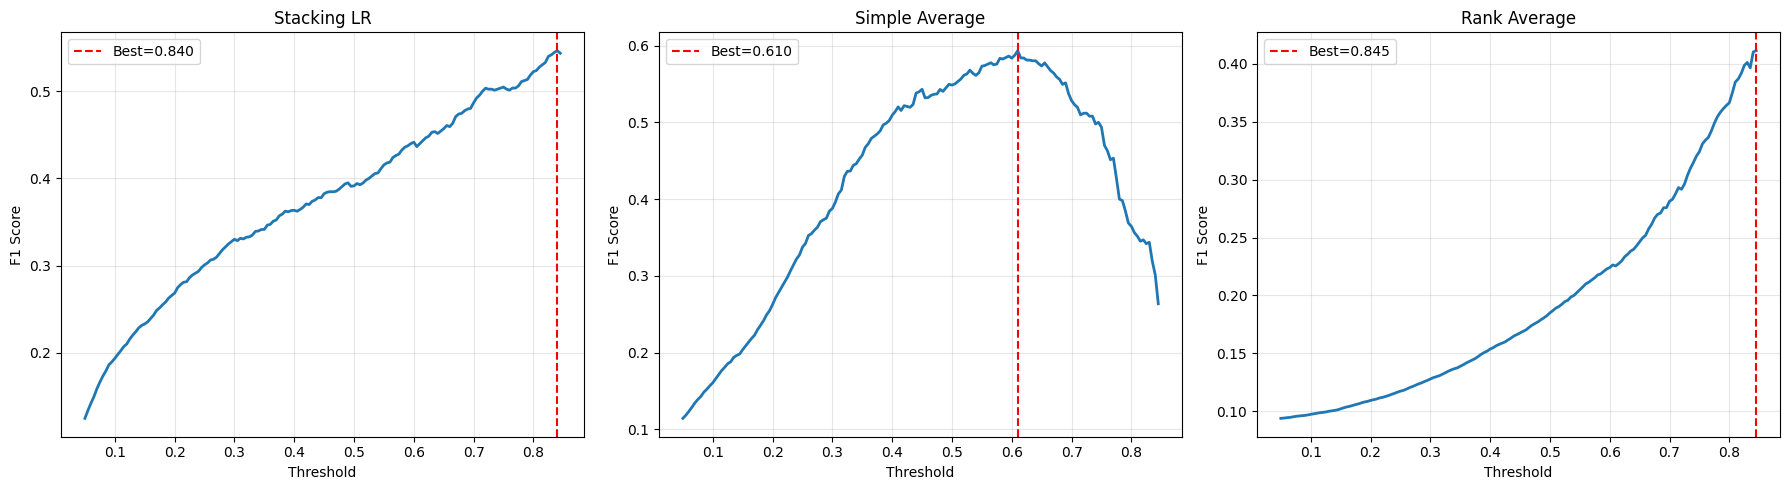

In [16]:
# F1 vs threshold curves for all methods
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (thrs, f1s, name, thr) in zip(axes, [
    (thrs_s, f1s_s, "Stacking LR", thr_stack),
    (thrs_a, f1s_a, "Simple Average", thr_avg),
    (thrs_r, f1s_r, "Rank Average", thr_rank),
]):
    ax.plot(thrs, f1s, linewidth=2)
    ax.axvline(thr, color="red", linestyle="--", label=f"Best={thr:.3f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("F1 Score")
    ax.set_title(name)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Using: simple_avg (threshold=0.610)

              precision    recall  f1-score   support

     Non-TDE       0.98      0.98      0.98      2895
         TDE       0.59      0.60      0.59       148

    accuracy                           0.96      3043
   macro avg       0.78      0.79      0.79      3043
weighted avg       0.96      0.96      0.96      3043



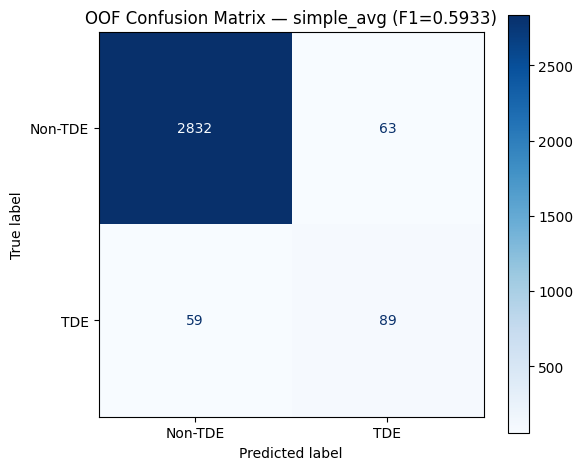

In [17]:
# Classification report & confusion matrix
oof_pred = (best_oof >= best_thr).astype(int)
print(f"Using: {best_method} (threshold={best_thr:.3f})\n")
print(classification_report(y, oof_pred, target_names=["Non-TDE", "TDE"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y, oof_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Non-TDE", "TDE"])
disp.plot(ax=ax, cmap="Blues")
ax.set_title(f"OOF Confusion Matrix — {best_method} (F1={best_f1:.4f})")
plt.tight_layout()
plt.show()

## 8. Per-Model Analysis

In [18]:
# Compare individual model performance
print("Individual model OOF F1 scores (at their own best thresholds):")
print("=" * 55)
for i, name in enumerate(model_names):
    thrs = np.arange(0.05, 0.85, 0.005)
    f1s = [f1_score(y, (oof_preds[:, i] >= t).astype(int)) for t in thrs]
    best_idx = np.argmax(f1s)
    print(f"  {name:20s}: F1={f1s[best_idx]:.4f} @ threshold={thrs[best_idx]:.3f}")

# Correlation between models
print(f"\nModel prediction correlations:")
corr_df = pd.DataFrame(oof_preds, columns=model_names).corr()
print(corr_df.round(3))

Individual model OOF F1 scores (at their own best thresholds):
  LightGBM            : F1=0.5918 @ threshold=0.655
  XGBoost             : F1=0.5867 @ threshold=0.665
  CatBoost            : F1=0.5093 @ threshold=0.555
  ExtraTrees          : F1=0.4224 @ threshold=0.565
  BalancedRF          : F1=0.4780 @ threshold=0.665

Model prediction correlations:
            LightGBM  XGBoost  CatBoost  ExtraTrees  BalancedRF
LightGBM       1.000    0.968     0.737       0.567       0.596
XGBoost        0.968    1.000     0.766       0.592       0.622
CatBoost       0.737    0.766     1.000       0.836       0.899
ExtraTrees     0.567    0.592     0.836       1.000       0.917
BalancedRF     0.596    0.622     0.899       0.917       1.000


## 9. Feature Importance

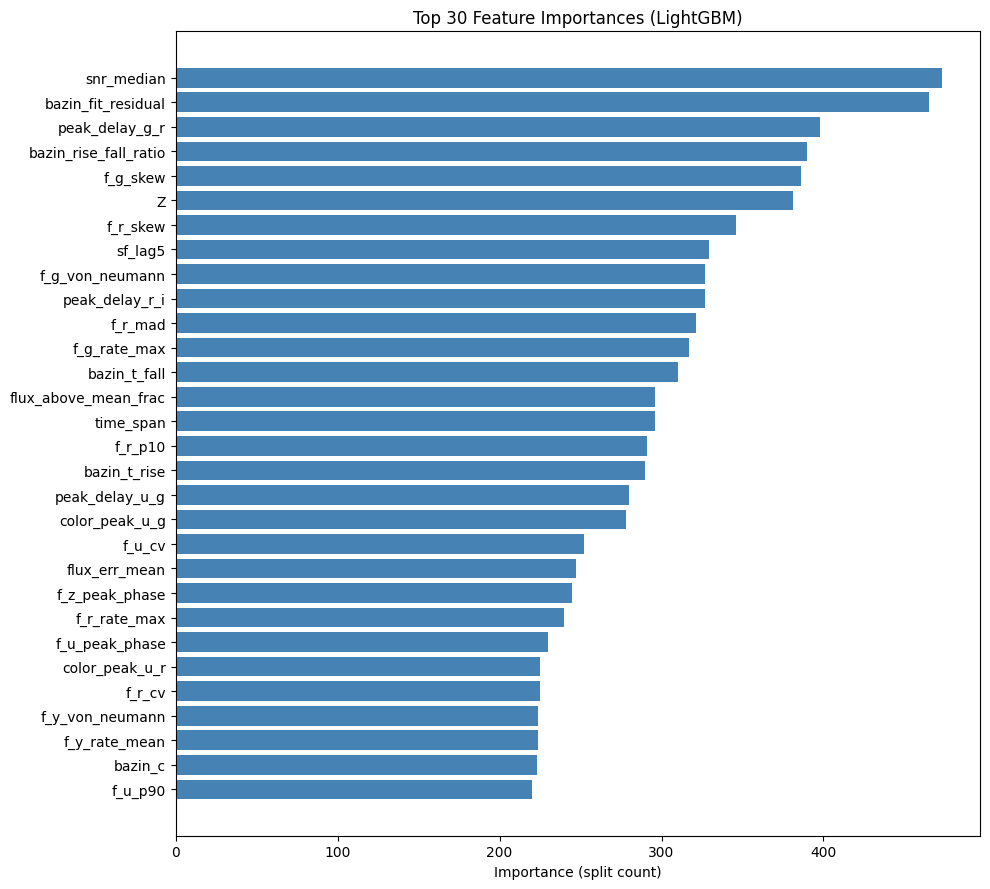


Total features: 267
Features with importance > 0: 264


In [19]:
# Train final LightGBM on all data for feature importance
lgb_full = lgb.LGBMClassifier(**{**lgb_params, "n_estimators": 1500})
lgb_full.fit(X, y)

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": lgb_full.feature_importances_
}).sort_values("importance", ascending=False)

top_n = 30
top_feats = importance.head(top_n)

plt.figure(figsize=(10, 9))
plt.barh(range(top_n), top_feats["importance"].values[::-1], color="steelblue")
plt.yticks(range(top_n), top_feats["feature"].values[::-1])
plt.xlabel("Importance (split count)")
plt.title(f"Top {top_n} Feature Importances (LightGBM)")
plt.tight_layout()
plt.show()

print(f"\nTotal features: {len(feature_cols)}")
print(f"Features with importance > 0: {(importance['importance'] > 0).sum()}")

## 10. Generate Submission

In [20]:
# Final prediction on test set using the best ensemble method
submission = pd.DataFrame({
    "object_id": test_log["object_id"],
    "prediction": (best_test_pred >= best_thr).astype(int),
})

# Sanity checks
sample = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert list(submission.columns) == list(sample.columns), "Column mismatch!"
assert len(submission) == len(sample), "Row count mismatch!"

print(f"Ensemble method: {best_method}")
print(f"Threshold: {best_thr:.3f}")
print(f"OOF F1: {best_f1:.4f}")
print(f"\nSubmission shape: {submission.shape}")
print(f"Predicted TDEs: {submission['prediction'].sum()} / {len(submission)} ({submission['prediction'].mean():.2%})")
print(f"\nPrediction distribution:")
print(submission["prediction"].value_counts())

submission.to_csv("submission.csv", index=False)
print("\nSaved to submission.csv")
submission.head(10)

Ensemble method: simple_avg
Threshold: 0.610
OOF F1: 0.5933

Submission shape: (7135, 2)
Predicted TDEs: 353 / 7135 (4.95%)

Prediction distribution:
prediction
0    6782
1     353
Name: count, dtype: int64

Saved to submission.csv


,object_id,prediction
0,Eluwaith_Mithrim_nothrim,0
1,Eru_heledir_archam,0
2,Gonhir_anann_fuin,0
3,Gwathuirim_haradrim_tegilbor,0
4,achas_minai_maen,0
5,adab_fae_gath,0
6,adel_draug_gaur,0
7,aderthad_cuil_galadhrim,0
8,aegas_laug_ithildin,0
9,aegas_mereth_law,0


In [21]:
# Also save alternative submissions for comparison
for method_name, _, thr, _, test_pred in results:
    sub = pd.DataFrame({
        "object_id": test_log["object_id"],
        "prediction": (test_pred >= thr).astype(int),
    })
    fname = f"submission_{method_name}.csv"
    sub.to_csv(fname, index=False)
    print(f"{fname}: {sub['prediction'].sum()} TDEs predicted")

print("\nDone! Try submitting each to see which generalizes best.")

submission_simple_avg.csv: 353 TDEs predicted
submission_stacking.csv: 511 TDEs predicted
submission_rank_avg.csv: 978 TDEs predicted

Done! Try submitting each to see which generalizes best.
